# DSC-515 Text Mining and Sentiment Analysis of Retail Customer Reviews

## Overview 
This project analyzes retail customer reviews using text mining and sentiment analysis to uncover patterns in language, classify review sentiment, and evaluate model performance. Through preprocessing, exploratory analysis, and machine learning, the project identifies key drivers of positive and negative feedback across product categories. The results support actionable recommendations aimed at improving customer satisfaction and addressing recurring issues in the customer experience.

## Preprocessing
Load the necessary libraries.

In [1]:
# Load libraries
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import nltk 
from nltk.probability import FreqDist
import janitor

Import the ASOS retail customer reviews dataset, which includes review text along with the date.

In [2]:
# Download the dataset folder
file_path = kagglehub.dataset_download("mahirahmzh/asos-customer-review-in-trustpilot")

# Load the ASOS reviews CSV
df_reviews = pd.read_csv(f"{file_path}/asos_transform.csv")
df_reviews = df_reviews.clean_names()

# Preview
print(df_reviews.shape)
print(df_reviews.head())
print(df_reviews.info())

(2000, 3)
                                               title  \
0                                        I love ASOS   
1                           Quality customer service   
2                        Helpful and friendly staff.   
3               Replied quickly and made sure their…   
4  Helpful customer service officer but problemat...   

                                            contents          date  
0  I love ASOS and allCustomer service they are j...  Dec 14, 2019  
1  My order was left outside and the school kids ...  Dec 14, 2019  
2                        Helpful and friendly staff.  Dec 14, 2019  
3  Replied quickly and made sure their customers ...  Dec 14, 2019  
4  Rebecca was patient and helpful with my querie...  Dec 14, 2019  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     2000 non-null   object
 1   contents  2000

Basic preprocessing (missing values, duplicates, and date formatting).

In [3]:
# Summary statistics (all columns are text/object)
print(df_reviews.describe(include='object'))

# Check for missing values
print(df_reviews.isnull().sum()) # No missing values in this dataset

# Check for duplicates
duplicates = df_reviews[df_reviews.duplicated(keep=False)]
duplicates

# There are 12 duplicate rows across all columns. Will remove and treat the remaining values as unique reviews.
df_reviews = df_reviews.drop_duplicates()

# Check
print(df_reviews.duplicated().sum()) # 0

# Remove leading words from the 'date' column (e.g., "Reviewed on ")
df_reviews['date'] = df_reviews['date'].str.replace(r'^(Updated|Reported)\s+', '', regex=True)

# Count of frequency by date
date_counts = df_reviews['date'].value_counts()
print(date_counts)

# Convert date column to datetime (yyyy-mm-dd)
df_reviews['date'] = pd.to_datetime(df_reviews['date'], format='%b %d, %Y')
df_reviews['date'] = df_reviews['date'].dt.date

# Count of frequency by date after conversion
date_counts_converted = df_reviews['date'].value_counts()

                         title      contents         date
count                     2000          2000         2000
unique                    1834          1962           30
top     Great customer service  Very helpful  Dec 2, 2019
freq                        20             6          197
title       0
contents    0
date        0
dtype: int64
0
date
Dec 2, 2019     201
Dec 10, 2019    192
Dec 9, 2019     177
Dec 6, 2019     164
Dec 11, 2019    162
Dec 7, 2019     158
Dec 3, 2019     145
Dec 5, 2019     143
Dec 13, 2019    124
Dec 8, 2019     124
Dec 12, 2019    120
Dec 4, 2019     117
Dec 14, 2019     93
Dec 1, 2019      74
Name: count, dtype: int64


For preprocessing, punctuation and special characters are removed, text is lowercased, and stemming or lemmatization is applied to standardize the reviews for later modeling and exploratory analysis. A separate copy of the original text is preserved for VADER sentiment analysis, since VADER relies on punctuation and other cues that are lost during cleaning. The reviews are unstructured text, and numeric values are retained because dates and delivery ranges often provide meaningful context.

In [4]:
# Download NLTK resources
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Keep original text for VADER
df_reviews = df_reviews.rename(columns={'contents': 'contents_raw'})

# Create a cleaned version for NLP tasks
df_reviews['contents_clean'] = df_reviews['contents_raw'].str.lower()

# Check unique values after lowercasing
unique_contents_lower = df_reviews['contents_clean'].nunique()
print(f"Number of unique contents after lowercasing: {unique_contents_lower}")

# Remove punctuation, numbers, and special characters (preserving dates and ranges)
df_reviews['contents_clean'] = df_reviews['contents_clean'].str.replace(r'[^\w\s/-]', '', regex=True)

# Remove URLs
df_reviews['contents_clean'] = df_reviews['contents_clean'].str.replace(r'http\S+|www.\S+', '', regex=True)

# Preview cleaned text
print(df_reviews['contents_clean'].head())

# Tokenize and remove stopwords using the cleaned text
stop_words = set(stopwords.words('english'))
df_reviews['tokens'] = df_reviews['contents_clean'].apply(word_tokenize)
df_reviews['tokens'] = df_reviews['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Any empty token lists after stopword removal?
empty_tokens = df_reviews[df_reviews['tokens'].apply(lambda x: len(x) == 0)]
print(empty_tokens)

# Remove rows with empty tokens
df_reviews = df_reviews[df_reviews['tokens'].apply(lambda x: len(x) > 0)]

# Finalized dataset after cleaning and tokenization
df_reviews_final = df_reviews[['date', 'contents_raw', 'contents_clean', 'tokens']]
print(df_reviews_final.head())
print(df_reviews_final.info())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tdjoh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tdjoh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tdjoh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of unique contents after lowercasing: 1953
0    i love asos and allcustomer service they are j...
1    my order was left outside and the school kids ...
2                           helpful and friendly staff
3    replied quickly and made sure their customers ...
4    rebecca was patient and helpful with my querie...
Name: contents_clean, dtype: object
   title      contents_raw        date contents_clean tokens
70  A+++  A+++++++++++++++  2019-12-14              a     []
         date                                       contents_raw  \
0  2019-12-14  I love ASOS and allCustomer service they are j...   
1  2019-12-14  My order was left outside and the school kids ...   
2  2019-12-14                        Helpful and friendly staff.   
3  2019-12-14  Replied quickly and made sure their customers ...   
4  2019-12-14  Rebecca was patient and helpful with my querie...   

                                      contents_clean  \
0  i love asos and allcustomer service they are j...

## Sentiment Analysis
Use VADER sentiment analysis to classify the sentiment of each review.

In [5]:
# Run Vader sentiment analysis on 'contents_raw'
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
df_reviews_final['sentiment_score'] = df_reviews_final['contents_raw'].apply(lambda x: analyzer.polarity_scores(x))
print(df_reviews_final[['contents_raw', 'sentiment_score']].head())

# Create sentiment class based on compound score
def sentiment_class(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_reviews_final['sentiment_class'] = df_reviews_final['sentiment_score'].apply(lambda x: sentiment_class(x['compound']))

# Descriptive stats of sentiment classes
sentiment_counts = df_reviews_final['sentiment_class'].value_counts()
print(sentiment_counts)

                                        contents_raw  \
0  I love ASOS and allCustomer service they are j...   
1  My order was left outside and the school kids ...   
2                        Helpful and friendly staff.   
3  Replied quickly and made sure their customers ...   
4  Rebecca was patient and helpful with my querie...   

                                     sentiment_score  
0  {'neg': 0.0, 'neu': 0.519, 'pos': 0.481, 'comp...  
1  {'neg': 0.0, 'neu': 0.793, 'pos': 0.207, 'comp...  
2  {'neg': 0.0, 'neu': 0.25, 'pos': 0.75, 'compou...  
3  {'neg': 0.0, 'neu': 0.538, 'pos': 0.462, 'comp...  
4  {'neg': 0.0, 'neu': 0.93, 'pos': 0.07, 'compou...  
sentiment_class
positive    1554
negative     336
neutral      103
Name: count, dtype: int64



## Exploratory Data Analysis (EDA)
Generate word clouds for positive and negative reviews, using cleaned text.

Positive Reviews Word Cloud


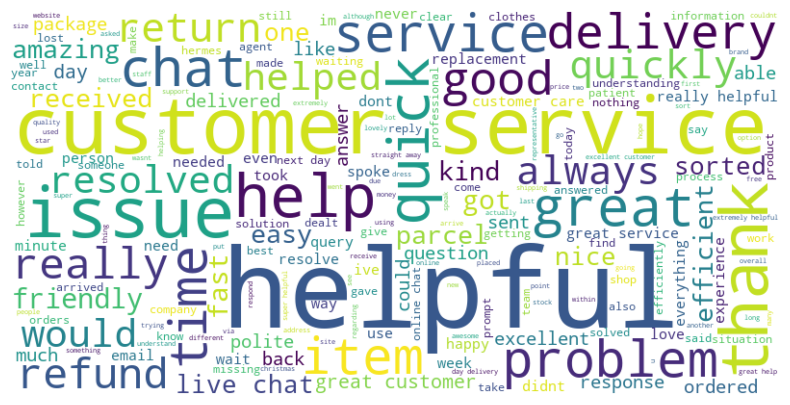

Negative Reviews Word Cloud


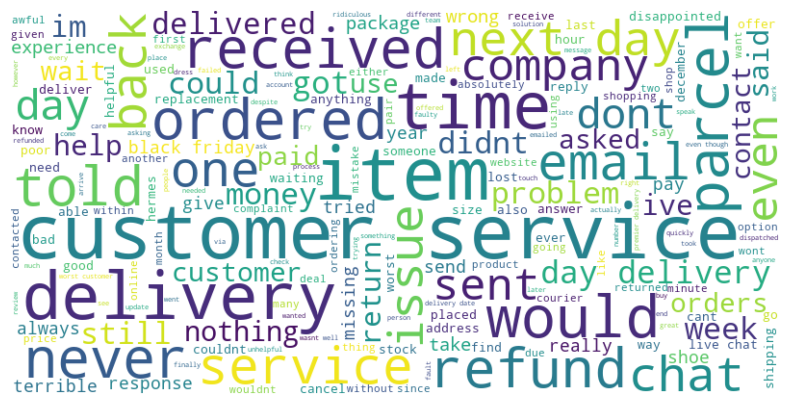

In [6]:
# Generate word clouds for positive and negative reviews 
from wordcloud import WordCloud

# Add custom stopword for company name
stop_words.update(["asos", "order", "get"])

# Combine text into single strings
positive_reviews = " ".join(
    df_reviews_final[df_reviews_final['sentiment_class'] == 'positive']['contents_clean']
)
negative_reviews = " ".join(
    df_reviews_final[df_reviews_final['sentiment_class'] == 'negative']['contents_clean']
)

# Create word clouds
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stop_words
).generate(positive_reviews)

negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stop_words
).generate(negative_reviews)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
print("Positive Reviews Word Cloud")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
print("Negative Reviews Word Cloud")
plt.show()



Use text mining to identify common terms by counting word frequencies and plotting the most frequent words in the dataset.

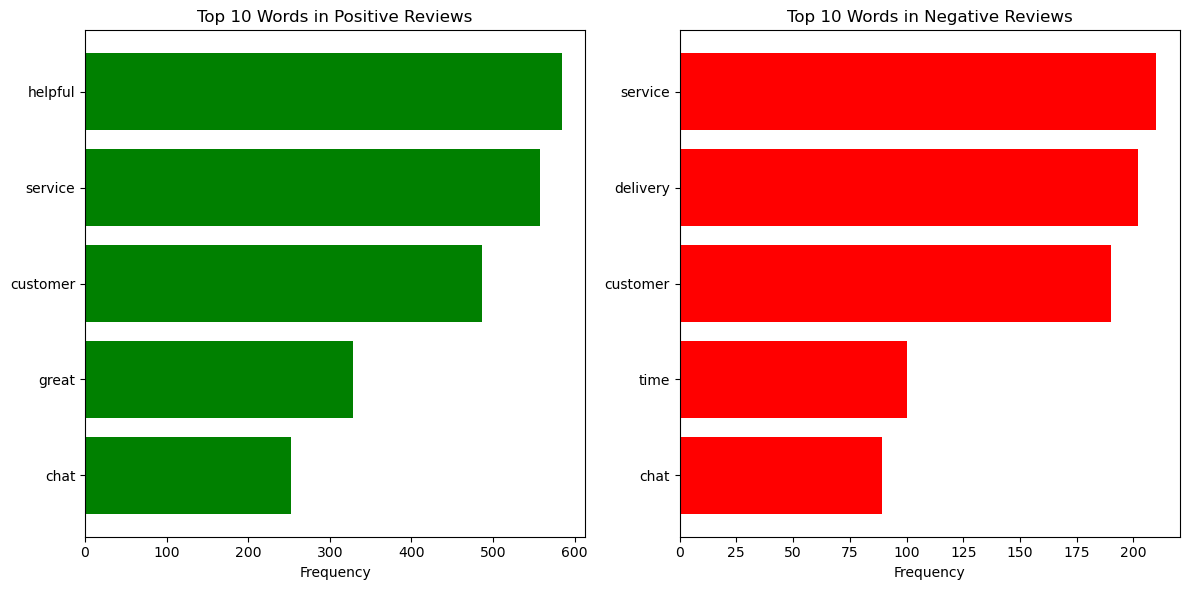

In [7]:
# Custom stop words
custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update(["asos", "order", "get"])

# Filter to positive and negative tokens
positive_tokens = df_reviews_final[df_reviews_final['sentiment_class'] == 'positive']['tokens']
negative_tokens = df_reviews_final[df_reviews_final['sentiment_class'] == 'negative']['tokens']

# Flatten and remove stop words
all_positive_words = [
    word for tokens in positive_tokens for word in tokens
    if word not in custom_stopwords
]
all_negative_words = [
    word for tokens in negative_tokens for word in tokens
    if word not in custom_stopwords
]

# Frequency distributions
freq_pos = FreqDist(all_positive_words)
freq_neg = FreqDist(all_negative_words)

# Get top 5 words
pos_top5 = freq_pos.most_common(5)
neg_top5 = freq_neg.most_common(5)

# Split into words and counts
pos_words, pos_counts = zip(*pos_top5)
neg_words, neg_counts = zip(*neg_top5)

# Plot horizontal bar charts
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh(pos_words, pos_counts, color='green')
plt.title("Top 10 Words in Positive Reviews")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.barh(neg_words, neg_counts, color='red')
plt.title("Top 10 Words in Negative Reviews")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model Development
The dataset was split into training and testing sets, and the text was converted into TF‑IDF features. A logistic regression model was trained to predict VADER’s rule‑based sentiment labels, allowing a direct comparison between strict lexicon scoring and a machine‑learning approach. Class weights were balanced to address the strong skew toward positive reviews and improve prediction of neutral and negative classes. Model performance was evaluated using accuracy, precision, recall, and F1‑score to assess how well the logistic model replicated VADER’s sentiment assignments.

In [8]:
# Model Development toolkit
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_tfidf = vectorizer.fit_transform(df_reviews_final['contents_clean'])

# Define X and y for modeling
X = X_tfidf
y = df_reviews_final['sentiment_class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes of the splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Fit a logistic regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict sentiment for the entire dataset
df_reviews_final['ml_sentiment_pred'] = model.predict(X_tfidf)

# Preview the updated DataFrame
df_reviews_final[['contents_clean', 'sentiment_class', 'ml_sentiment_pred']].head()

X_train shape: (1594, 5000)
X_test shape: (399, 5000)
y_train shape: (1594,)
y_test shape: (399,)
Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.72      0.64        67
     neutral       0.37      0.33      0.35        21
    positive       0.91      0.87      0.89       311

    accuracy                           0.81       399
   macro avg       0.62      0.64      0.63       399
weighted avg       0.83      0.81      0.82       399

Confusion Matrix:
[[ 48   2  17]
 [  5   7   9]
 [ 31  10 270]]


,contents_clean,sentiment_class,ml_sentiment_pred
0,i love asos and allcustomer service they are j...,positive,positive
1,my order was left outside and the school kids ...,positive,positive
2,helpful and friendly staff,positive,positive
3,replied quickly and made sure their customers ...,positive,positive
4,rebecca was patient and helpful with my querie...,positive,positive


## Insights and Recommendations
The rule‑based sentiment method produced labels that did not fully capture the range of sentiment expressed in the reviews. The logistic regression model, trained on TF‑IDF features, delivered more balanced and accurate predictions across negative, neutral, and positive classes. These results suggest that a machine‑learning approach can identify sentiment patterns more effectively than a fixed rule‑based system, especially when the underlying text contains slang, mixed emotions, or context‑dependent phrasing.

Certain words and phrases appeared across both positive and negative reviews, highlighting how sentiment depends on context rather than individual keywords. Terms like “customer” and “service” surfaced in both directions, showing that customer service is a central theme expressed with different emotional tones. Machine‑learning models can capture these contextual patterns more effectively than simple keyword counts, offering a stronger foundation for understanding what truly drives customer sentiment.

These insights also point to practical opportunities for improvement, especially because the dataset did not include predefined product or service categories. Negative reviews frequently referenced issues such as delivery delays and unmet expectations, while positive reviews emphasized helpful service interactions. A machine‑learning model that learns these distinctions directly from the text can not only identify sentiment but also surface the underlying themes that function as implicit categories—such as delivery, product quality, or customer service, even when they are not labeled like in the data. By uncovering these hidden groupings and linking them to sentiment patterns, machine‑learning approaches help organizations pinpoint the specific factors that influence satisfaction, prioritize operational improvements, and monitor emerging issues more effectively over time.

## References
Gupta, S. (2018, January 7). Sentiment analysis: Concept, analysis and applications. TDS Archive. Medium. https://medium.com/data-science/sentiment-analysis-concept-analysis-and-applications-6c94d6f58c17

IBM. (n.d.). What is sentiment analysis? https://www.ibm.com/think/topics/sentiment-analysis

Liu, A. (2024). ASOS Trustpilot review data from 2022 Oct–2023 Jan [Data set]. Kaggle. https://www.kaggle.com/datasets/anpoeliu/asos-trustpilot-review-data-from-2022-oct-2023-jan

NLTK Documentation: [Natural Language Toolkit](https://www.nltk.org/)

Jurafsky, D., & Martin, J. H. (2026). Logistic regression (Chap. 4). In Speech and language processing: An introduction to natural language processing, computational linguistics, and speech recognition with language models (3rd ed., draft). Stanford University. https://web.stanford.edu/~jurafsky/slp3/ed3book.pdf

Scikit-learn Documentation: [Scikit-learn](https://scikit-learn.org/stable/documentation.html)